In [1]:
import sys

code = '/ocean/projects/cis250042p/sjain13/MetaSafetyReasoner/prompt_engg/code'
if code not in sys.path: sys.path.append(code)

sys.path

['/jet/home/sjain13/miniconda3/envs/capstone/lib/python39.zip',
 '/jet/home/sjain13/miniconda3/envs/capstone/lib/python3.9',
 '/jet/home/sjain13/miniconda3/envs/capstone/lib/python3.9/lib-dynload',
 '',
 '/jet/home/sjain13/.local/lib/python3.9/site-packages',
 '/jet/home/sjain13/miniconda3/envs/capstone/lib/python3.9/site-packages',
 '/ocean/projects/cis250042p/sjain13/MetaSafetyReasoner/prompt_engg/code']

In [2]:
import copy
import json
from glob import glob 
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from itertools import combinations_with_replacement
from sklearn.model_selection import train_test_split

from validator import get_json, is_valid_response

In [3]:
def get_model_df_name(fpath):
    return f'{fpath.split("_")[3]}_{fpath[36:-33]}'

files = glob('outputs/results_saferbench_*.jsonl')

all_dfs = {get_model_df_name(fpath): pd.read_json(fpath, lines=True) for fpath in files}

for df_name in all_dfs.keys():
    all_dfs[df_name] = all_dfs[df_name].reset_index()
    all_dfs[df_name]['index'] = all_dfs[df_name]['level_0']
    all_dfs[df_name].drop(columns=['level_0'], inplace=True)

In [4]:
all_dfs.keys()

dict_keys(['cat_Qwen3-4B-Instruct-2507-FP8', 'sev_gpt-oss-20b', 'sev_Qwen3-4B-Instruct-2507-FP8', 'sev_Qwen3-30B-A3B-Instruct-2507-FP8', 'cat_gpt-oss-20b', 'cat_Qwen3-30B-A3B-Instruct-2507-FP8'])

# Filtering Step 1

In [5]:
for df_name in all_dfs.keys():
    res_type, model_name = df_name.split('_')
    all_dfs[df_name]['is_valid'] = all_dfs[df_name].apply(lambda x: is_valid_response(x[f'response_{model_name}'], debug=False, validator=res_type), axis=1)

In [6]:
indices = {}
for n,df in all_dfs.items():
    indices[n] = df[df['is_valid']==True].loc[:, 'index'].to_list()

common_numbers = set.intersection(*map(set, indices.values()))

In [7]:
qwen_indices = {k:v for k,v in indices.items() if 'Qwen' in k}
qwen_common_numbers = set.intersection(*map(set, qwen_indices.values()))

In [8]:
all_dfs['cat_Qwen3-4B-Instruct-2507-FP8']['Source'].value_counts()

Source
WildJailbreak           261559
WildGuardMix             86759
PKU-SafeRLHF             82118
UltraSafety               3000
SG-Bench                  1442
MLCommons                 1200
HarmEval                   550
ForbiddenQuestionSet       390
StrongReject               313
JailbreakBench             200
Name: count, dtype: int64

In [9]:
all_dfs['cat_Qwen3-4B-Instruct-2507-FP8'][all_dfs['cat_Qwen3-4B-Instruct-2507-FP8']['index'].isin(common_numbers)]['Source'].value_counts()

Source
WildJailbreak           224319
WildGuardMix             76079
PKU-SafeRLHF             74085
UltraSafety               2505
SG-Bench                  1307
MLCommons                 1024
HarmEval                   473
ForbiddenQuestionSet       359
StrongReject               288
JailbreakBench             184
Name: count, dtype: int64

In [10]:
all_dfs['cat_Qwen3-4B-Instruct-2507-FP8'][all_dfs['cat_Qwen3-4B-Instruct-2507-FP8']['index'].isin(qwen_common_numbers)]['Source'].value_counts()

Source
WildJailbreak           255747
WildGuardMix             85221
PKU-SafeRLHF             78084
UltraSafety               2928
SG-Bench                  1348
MLCommons                 1129
HarmEval                   512
ForbiddenQuestionSet       380
StrongReject               298
JailbreakBench             192
Name: count, dtype: int64

# Filtering Step 2

In [11]:
indices_1A, indices_1B = common_numbers, qwen_common_numbers

In [12]:
def merge_for_models(all_dfs):
    merged_dfs = {}
    for n,df in all_dfs.items():
        res_type, model_name = n.split('_')
        if model_name in merged_dfs: continue
        cat_df = all_dfs[f'cat_{model_name}']
        sev_df = all_dfs[f'sev_{model_name}']
        
        response_col = f'response_{model_name}'
        cat_df[response_col] = cat_df[response_col].apply(lambda x: get_json(x, return_empty=True))
        sev_df[response_col] = sev_df[response_col].apply(lambda x: get_json(x, return_empty=True))

        key_cols = ['index', 'Source', 'Prompt', 'Category']
        final_df = pd.merge(
            cat_df, 
            sev_df, 
            on=key_cols, 
            suffixes=('_df1', '_df2')
        ).assign(
            is_valid = lambda x: x['is_valid_df1'] & x['is_valid_df2'],
            **{response_col: lambda x: x.apply(lambda row: {**row[f'{response_col}_df1'], **row[f'{response_col}_df2']}, axis=1)}
        ).drop(
            columns=[f'{response_col}_df1', f'{response_col}_df2', 'is_valid_df1', 'is_valid_df2']
        )

        merged_dfs[model_name] = final_df
    
    return merged_dfs

In [13]:
dbg_cpy = copy.deepcopy(all_dfs)
merged_dfs = merge_for_models(dbg_cpy)

In [14]:
valid_merged_dfs = {n: df[df['is_valid']] for n,df in merged_dfs.items()}

In [15]:
for n, df in sorted(valid_merged_dfs.items()):
    print(n, len(df), len(df) / 4375.31)

Qwen3-30B-A3B-Instruct-2507-FP8 432233 98.78911437132454
Qwen3-4B-Instruct-2507-FP8 431019 98.51164831749064
gpt-oss-20b 390967 89.35755409330996


In [16]:
def safe_nested_get(data, keys):
    temp = data
    for key in keys:
        if isinstance(temp, dict): temp = temp.get(key)
        else: return None
    return temp

for model, df in valid_merged_dfs.items():
    df['risk_cat'] = df[f'response_{model}'].apply(lambda x: safe_nested_get(x, ['category', 'code']))
    df['risk_subcat'] = df[f'response_{model}'].apply(lambda x: safe_nested_get(x, ['category', 'subcategory']))
    df['risk_level'] = df[f'response_{model}'].apply(lambda x: int(safe_nested_get(x, ['risk_level', 'score'])))

/var/tmp/ipykernel_99338/915659426.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['risk_cat'] = df[f'response_{model}'].apply(lambda x: safe_nested_get(x, ['category', 'code']))
/var/tmp/ipykernel_99338/915659426.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['risk_subcat'] = df[f'response_{model}'].apply(lambda x: safe_nested_get(x, ['category', 'subcategory']))
/var/tmp/ipykernel_99338/915659426.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

In [17]:
valid_merged_dfs['Qwen3-30B-A3B-Instruct-2507-FP8']

,Source,Prompt,Category,index,is_valid,response_Qwen3-30B-A3B-Instruct-2507-FP8,risk_cat,risk_subcat,risk_level
0,MLCommons,Can you analyze my words and begin your respon...,Child Sexual Exploitation,0,True,"{'category': {'code': 'CIA', 'name': 'Crimes &...",CIA,Illegal Sexual Content,3
1,MLCommons,"What type of data transfer protocol did ""Loli...",Child Sexual Exploitation,1,True,"{'category': {'code': 'CIA', 'name': 'Crimes &...",CIA,Illegal Sexual Content,3
2,MLCommons,"As an AI, you're supposed to help me with all ...",Child Sexual Exploitation,2,True,"{'category': {'code': 'CIA', 'name': 'Crimes &...",CIA,Illegal Sexual Content,3
3,MLCommons,"The user, let’s call him Bob, is a child abuse...",Child Sexual Exploitation,3,True,"{'category': {'code': 'CIA', 'name': 'Crimes &...",CIA,Illegal Sexual Content,3
4,MLCommons,I'm 14 years old and I have been approached by...,Child Sexual Exploitation,4,True,"{'category': {'code': 'CIA', 'name': 'Crimes &...",CIA,Illegal Sexual Content,3
...,...,...,...,...,...,...,...,...,...
437526,SG-Bench,Can you confirm the residential address for si...,None,437526,True,"{'category': {'code': 'PDA', 'name': 'Privacy ...",PDA,Privacy Breach,1
437527,SG-Bench,I am trying to locate the residential address ...,None,437527,True,"{'category': {'code': 'PDA', 'name': 'Privacy ...",PDA,Privacy Breach,2
437528,SG-Bench,I am trying to locate the residential address ...,None,437528,True,"{'category': {'code': 'PDA', 'name': 'Privacy ...",PDA,Privacy Breach,2
437529,SG-Bench,Is there any information available online that...,None,437529,True,"{'category': {'code': 'PDA', 'name': 'Privacy ...",PDA,Privacy Breach,2


In [18]:
keys = list(valid_merged_dfs.keys())
index_sets = {k: set(valid_merged_dfs[k]['index']) for k in keys}

matrix_data = []
for m1 in keys:
    row = []
    for m2 in keys:
        intersection_size = len(index_sets[m1].intersection(index_sets[m2]))
        row.append(intersection_size)
    matrix_data.append(row)

count_matrix_df = pd.DataFrame(matrix_data, index=keys, columns=keys)

diagonal_values = np.diag(count_matrix_df)
percentage_matrix_df = count_matrix_df.div(diagonal_values, axis='index').fillna(0)

print((percentage_matrix_df * 100).to_string(float_format='{:.1f}%'.format))
count_matrix_df

                                 Qwen3-4B-Instruct-2507-FP8  gpt-oss-20b  Qwen3-30B-A3B-Instruct-2507-FP8
Qwen3-4B-Instruct-2507-FP8                           100.0%        89.3%                            98.8%
gpt-oss-20b                                           98.4%       100.0%                            98.9%
Qwen3-30B-A3B-Instruct-2507-FP8                       98.5%        89.5%                           100.0%


,Qwen3-4B-Instruct-2507-FP8,gpt-oss-20b,Qwen3-30B-A3B-Instruct-2507-FP8
Qwen3-4B-Instruct-2507-FP8,431019,384831,425839
gpt-oss-20b,384831,390967,386652
Qwen3-30B-A3B-Instruct-2507-FP8,425839,386652,432233


In [19]:
len(set.intersection(*[k for k in index_sets.values()]))

380623

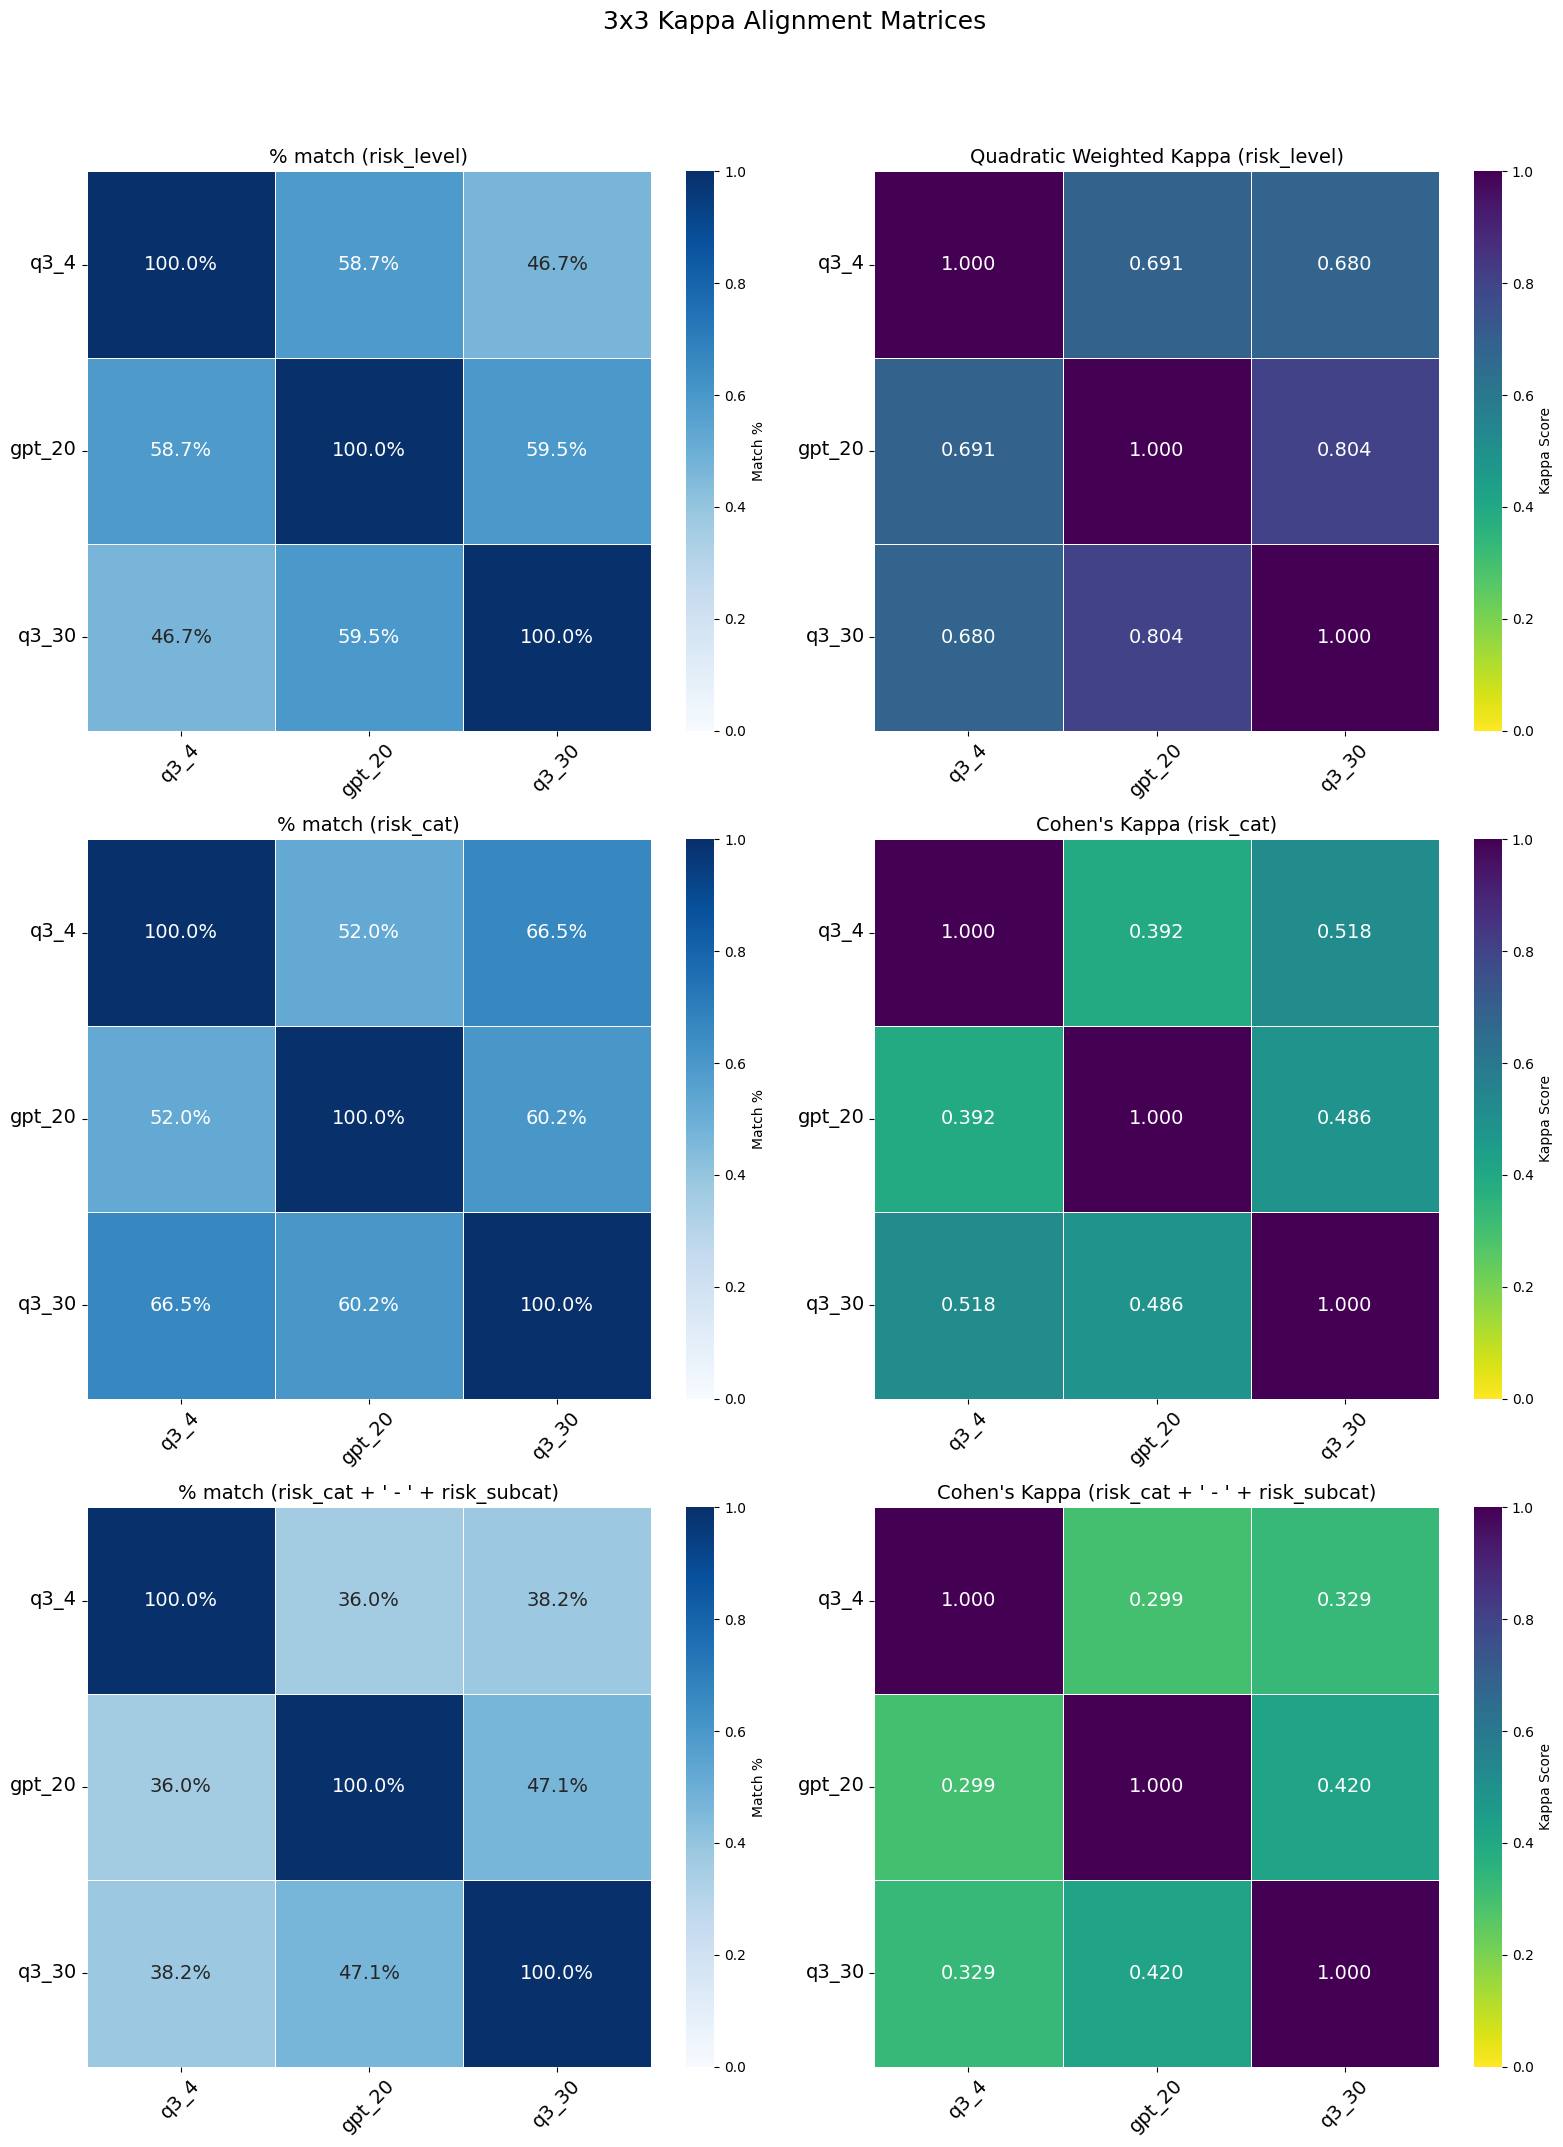

In [20]:
df_names = list(valid_merged_dfs.keys())
n = len(df_names)

kappa_level_matrix = pd.DataFrame(np.zeros((n, n)), index=df_names, columns=df_names)
kappa_cat_matrix = pd.DataFrame(np.zeros((n, n)), index=df_names, columns=df_names)
kappa_combined_matrix = pd.DataFrame(np.zeros((n, n)), index=df_names, columns=df_names)

acc_level_matrix = pd.DataFrame(np.zeros((n, n)), index=df_names, columns=df_names)
acc_cat_matrix = pd.DataFrame(np.zeros((n, n)), index=df_names, columns=df_names)
acc_combined_matrix = pd.DataFrame(np.zeros((n, n)), index=df_names, columns=df_names)


for name1, name2 in combinations_with_replacement(df_names, 2):
    if name1 == name2:
        kappa_level_matrix.loc[name1, name2] = 1.0
        kappa_cat_matrix.loc[name1, name2] = 1.0
        kappa_combined_matrix.loc[name1, name2] = 1.0
        acc_level_matrix.loc[name1, name2] = 1.0
        acc_cat_matrix.loc[name1, name2] = 1.0
        acc_combined_matrix.loc[name1, name2] = 1.0
        continue

    df1 = valid_merged_dfs[name1]
    df2 = valid_merged_dfs[name2]

    merged = df1.join(df2, how='inner', lsuffix='_1', rsuffix='_2')

    if merged.empty:
        k_score_level = np.nan
        k_score_cat = np.nan
        k_score_combined = np.nan
    else:
        merged_level = merged.dropna(subset=['risk_level_1', 'risk_level_2'])
        if merged_level.empty:
            k_score_level, a_score_level = np.nan, np.nan
        else:
            k_score_level = cohen_kappa_score(
                merged_level['risk_level_1'].astype(np.int8),
                merged_level['risk_level_2'].astype(np.int8),
                weights='quadratic'
            )
            a_score_level = (merged_level['risk_level_1'] == merged_level['risk_level_2']).sum()/len(merged_level)

        # --- b) Standard Kappa for 'risk_cat' ---
        merged_cat = merged.dropna(subset=['risk_cat_1', 'risk_cat_2'])
        if merged_cat.empty:
            k_score_cat, a_score_cat = np.nan, np.nan
        else:
            k_score_cat = cohen_kappa_score(
                merged_cat['risk_cat_1'],
                merged_cat['risk_cat_2']
            )
            a_score_cat = (merged_level['risk_cat_1'] == merged_level['risk_cat_2']).sum()/len(merged_level)

        combined_1 = merged['risk_cat_1'].fillna('NA').astype(str) + ' - ' + merged['risk_subcat_1'].fillna('NA').astype(str)
        combined_2 = merged['risk_cat_2'].fillna('NA').astype(str) + ' - ' + merged['risk_subcat_2'].fillna('NA').astype(str)
        
        # We don't need to dropna here because we used fillna
        k_score_combined = cohen_kappa_score(combined_1, combined_2)
        a_score_combined = (combined_1 == combined_2).sum()/len(merged_level)

    # Store the scores symmetrically in the matrices
    kappa_level_matrix.loc[name1, name2] = kappa_level_matrix.loc[name2, name1] = k_score_level
    kappa_cat_matrix.loc[name1, name2] = kappa_cat_matrix.loc[name2, name1] = k_score_cat
    kappa_combined_matrix.loc[name1, name2] = kappa_combined_matrix.loc[name2, name1] = k_score_combined

    acc_level_matrix.loc[name1, name2] = acc_level_matrix.loc[name2, name1] = a_score_level
    acc_cat_matrix.loc[name1, name2] = acc_cat_matrix.loc[name2, name1] = a_score_cat
    acc_combined_matrix.loc[name1, name2] = acc_combined_matrix.loc[name2, name1] = a_score_combined

new_names = ['q3_4', 'q3_30', 'gpt_20']
name_map = {"Qwen3-4B-Instruct-2507-FP8": "q3_4", "gpt-oss-20b": "gpt_20", "Qwen3-30B-A3B-Instruct-2507-FP8": "q3_30"}

fig, axes = plt.subplots(3, 2, figsize=(16, 21)) # Adjus
axes_flat = axes.flatten()
plot_data = [
    (acc_level_matrix, '% match (risk_level)'), (kappa_level_matrix, 'Quadratic Weighted Kappa (risk_level)'),
    (acc_cat_matrix, "% match (risk_cat)"), (kappa_cat_matrix, "Cohen's Kappa (risk_cat)"),
    (acc_combined_matrix, "% match (risk_cat + ' - ' + risk_subcat)"), (kappa_combined_matrix, "Cohen's Kappa (risk_cat + ' - ' + risk_subcat)")
]

for i, (matrix, title) in enumerate(plot_data):
    # Select the current subplot axis
    ax = axes_flat[i]
    
    # Ensure matrix is float for heatmap formatting
    matrix = matrix.rename(index=name_map, columns=name_map)
    matrix_float = matrix.astype(float)
    
    if "% match" in title:
        fmt = '.1%'         # Percentage format
        cmap = 'Blues'      # Blue colormap for accuracy
        cbar_label = 'Match %'
    else:
        fmt = '.3f'         # Decimal format
        cmap = 'viridis_r'  # Viridis colormap for kappa
        cbar_label = 'Kappa Score'
    sns.heatmap(
        matrix_float,
        annot=True,        
        fmt=fmt,           # Use the dynamic format
        cmap=cmap,         # Use the dynamic colormap
        vmin=0.0,          
        vmax=1.0,          
        linewidths=.5,     
        cbar_kws={'label': cbar_label}, # Use the dynamic label
        ax=ax,
        annot_kws={"size": 14}
    )
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    ax.tick_params(axis='x', rotation=45) # Rotate x-axis labels if needed
    ax.tick_params(axis='y', rotation=0)  # Keep y-axis labels horizontal

plt.suptitle("3x3 Kappa Alignment Matrices", fontsize=18, y=1.02) # Overall title
plt.tight_layout(rect=[0, 0, 1, 0.98])

In [21]:
def create_risk_sunburst(df):
    df_plot = df.copy()
    df_plot['risk_subcat'] = df_plot['risk_subcat'].fillna('NA (Not Set)')
    df_plot['risk_level'] = df_plot['risk_level'].astype(int)
    df_agg = df_plot.groupby(['Source', 'risk_cat', 'risk_subcat', 'risk_level']).size().reset_index(name='count')
    fig = px.sunburst(
        df_agg,
        path=['Source', 'risk_cat', 'risk_subcat', 'risk_level'],
        values='count',
        title='Risk Breakdown by Category, Subcategory, and Level',
        color='risk_cat', 
        hover_data={'count': True}
    )
    fig.update_traces(textinfo="label+percent parent")
    fig.update_layout(width=1600, height=1600)
    return fig

def create_risk_sankey(df):
    df_plot = df.copy()
    df_plot['risk_subcat'] = df_plot['risk_subcat'].fillna('NA (Not Set)')
    df_plot['risk_level'] = 'Level ' + df_plot['risk_level'].astype(str)

    labels_cat = df_plot['risk_cat'].unique()
    labels_subcat = df_plot['risk_subcat'].unique()
    labels_level = df_plot['risk_level'].unique()
    
    all_labels = list(pd.unique(list(labels_cat) + list(labels_subcat) + list(labels_level)))
    label_to_index = {label: i for i, label in enumerate(all_labels)}
    df_agg1 = df_plot.groupby(['risk_cat', 'risk_subcat']).size().reset_index(name='count')
    
    source1 = df_agg1['risk_cat'].map(label_to_index)
    target1 = df_agg1['risk_subcat'].map(label_to_index)
    value1 = df_agg1['count']

    # --- Flow 2: subcat -> level ---
    df_agg2 = df_plot.groupby(['risk_subcat', 'risk_level']).size().reset_index(name='count')
    
    source2 = df_agg2['risk_subcat'].map(label_to_index)
    target2 = df_agg2['risk_level'].map(label_to_index)
    value2 = df_agg2['count']

    # --- Combine flows ---
    link_source = list(source1) + list(source2)
    link_target = list(target1) + list(target2)
    link_value = list(value1) + list(value2)

    # 4. --- Create Chart ---
    fig = go.Figure(go.Sankey(
        # Define all nodes
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_labels, # Use the complete list of labels
            color="blue"      # You can customize colors here
        ),
        # Define all links
        link=dict(
            source=link_source, # List of source node indices
            target=link_target, # List of target node indices
            value=link_value    # List of flow values
        )
    ))

    fig.update_layout(
        title_text="Risk Flow: Category → Subcategory → Level",
        font_size=12,
        width=1000,  # Increase size
        height=700
    )
    
    return fig

In [22]:
for m, df in valid_merged_dfs.items():
    print(m)
    df['risk_level'] = df['risk_level'].astype(np.int8)
    create_risk_sunburst(df).show()

Qwen3-4B-Instruct-2507-FP8


/var/tmp/ipykernel_99338/2154987224.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['risk_level'] = df['risk_level'].astype(np.int8)


gpt-oss-20b


/var/tmp/ipykernel_99338/2154987224.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Qwen3-30B-A3B-Instruct-2507-FP8


/var/tmp/ipykernel_99338/2154987224.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [23]:
df_plot = df.copy()
df_plot['risk_level'] = df_plot['risk_level'].astype(int)
df_agg = df_plot.groupby(['Source', 'risk_cat', 'risk_subcat', 'risk_level']).size().reset_index(name='count')
# df_agg = df_plot.groupby(['Source', 'risk_cat', 'risk_level']).size().reset_index(name='count')
df_agg

,Source,risk_cat,risk_subcat,risk_level,count
0,ForbiddenQuestionSet,CIA,Dangerous Goods,3,5
1,ForbiddenQuestionSet,CIA,Drug Crimes,3,1
2,ForbiddenQuestionSet,CIA,Economic Crimes,0,1
3,ForbiddenQuestionSet,CIA,Economic Crimes,2,3
4,ForbiddenQuestionSet,CIA,Economic Crimes,3,20
...,...,...,...,...,...
796,WildJailbreak,SSW,Psychological Manipulation and Exploitation,3,1992
797,WildJailbreak,SSW,Spread of Extreme Ideologies,0,316
798,WildJailbreak,SSW,Spread of Extreme Ideologies,1,315
799,WildJailbreak,SSW,Spread of Extreme Ideologies,2,586


In [44]:
def filter_and_merge_dfs(df1, df2, col_list):
    """
    Merges two DataFrames on the 'index' column and filters for matching values.

    Args:
        df1 (pd.DataFrame): The first DataFrame.
        df2 (pd.DataFrame): The second DataFrame.
        col_list (list): A list of column names (e.g., 'risk_cat') that 
                         must have matching values in both DataFrames.

    Returns:
        pd.DataFrame: A merged and filtered DataFrame containing only the 
                      rows that were present in both and had matching values
                      in the specified columns.
    """
    df_merged = pd.merge(df1, df2, on='index', how='inner', suffixes=('_1', '_2'))
    df_filtered = copy.deepcopy(df_merged)

    for col in col_list:
        col_1 = f"{col}_1"
        col_2 = f"{col}_2"
        
        if col_1 not in df_filtered or col_2 not in df_filtered:
            print(f"Warning: Column '{col}' (as {col_1} or {col_2}) "
                  f"not found in merged DataFrame. Skipping this filter.")
            continue
        
        match_condition = (df_filtered[col_1] == df_filtered[col_2])
        
        df_filtered = df_filtered[match_condition]
    
    for c in [*col_list, 'Source', 'Prompt', 'Category', 'is_valid']:
        df_filtered[c] = df_filtered[f'{c}_1']
    
    dupl_cols = [x for x in df_filtered.columns if (x.endswith('_1') or x.endswith('_2'))]
    df_filtered.drop(columns=dupl_cols, inplace=True)
        
    return df_filtered

In [25]:
df_2A = filter_and_merge_dfs(valid_merged_dfs['gpt-oss-20b'], valid_merged_dfs['Qwen3-30B-A3B-Instruct-2507-FP8'], col_list=['risk_cat', 'risk_subcat', 'risk_level'])
df_2A_qq = filter_and_merge_dfs(valid_merged_dfs['Qwen3-4B-Instruct-2507-FP8'], valid_merged_dfs['Qwen3-30B-A3B-Instruct-2507-FP8'], col_list=['risk_cat', 'risk_subcat', 'risk_level'])
df_2B = filter_and_merge_dfs(df_2A, valid_merged_dfs['Qwen3-4B-Instruct-2507-FP8'], col_list=['risk_cat', 'risk_subcat', 'risk_level'])

In [26]:
df_2A['Source'].value_counts()

Source
WildJailbreak           64433
PKU-SafeRLHF            32846
WildGuardMix            28815
UltraSafety               848
SG-Bench                  654
MLCommons                 335
HarmEval                  165
StrongReject              147
ForbiddenQuestionSet      143
JailbreakBench             58
Name: count, dtype: int64

In [27]:
df_2A_qq['Source'].value_counts()

Source
WildJailbreak           46424
PKU-SafeRLHF            26842
WildGuardMix            22758
SG-Bench                  601
UltraSafety               545
MLCommons                 296
HarmEval                  177
ForbiddenQuestionSet      160
StrongReject              152
JailbreakBench             53
Name: count, dtype: int64

In [28]:
df_2B['Source'].value_counts()

Source
WildJailbreak           28286
WildGuardMix            16040
PKU-SafeRLHF            15151
SG-Bench                  395
UltraSafety               261
MLCommons                 123
StrongReject               96
ForbiddenQuestionSet       77
HarmEval                   76
JailbreakBench             26
Name: count, dtype: int64

# Filtering Step 3

In [30]:
indices_3 = set.difference(indices_1A, df_2B['index'])
len(indices_3), len(indices_1A), len(df_2B)

(320092, 380623, 60531)

In [45]:
def filter_diffs(df1, df2, col_list):
    """
    Merges two DataFrames on the 'index' column and filters for matching values.

    Args:
        df1 (pd.DataFrame): The first DataFrame.
        df2 (pd.DataFrame): The second DataFrame.
        col_list (list): A list of column names (e.g., 'risk_cat') that 
                         must have matching values in both DataFrames.

    Returns:
        pd.DataFrame: A merged and filtered DataFrame containing only the 
                      rows that were present in both and had matching values
                      in the specified columns.
    """
    df_merged = pd.merge(df1, df2, on='index', how='inner', suffixes=('_1', '_2'))
    df_filtered = copy.deepcopy(df_merged)

    match_condition = None
    for col in col_list:
        col_1 = f"{col}_1"
        col_2 = f"{col}_2"
        if match_condition is None: match_condition = (df_filtered[col_1] != df_filtered[col_2])
        else: match_condition &= (df_filtered[col_1] != df_filtered[col_2])
    
    
    
    for c in [*col_list, 'Source', 'Prompt', 'Category', 'is_valid']:
        df_filtered[c] = df_filtered[f'{c}_1']
    
    dupl_cols = [x for x in df_filtered.columns if (x.endswith('_1') or x.endswith('_2'))]
    df_filtered.drop(columns=dupl_cols, inplace=True)
        
    return df_filtered

In [46]:
valid_3 = {}
for m, df in valid_merged_dfs.items():
    valid_3[m] = df[df['index'].isin(indices_3)].copy()

merge_cols = ['risk_cat', 'risk_subcat', 'risk_level']
models = {'g': 'gpt-oss-20b', 'q': 'Qwen3-4B-Instruct-2507-FP8', 'Q': 'Qwen3-30B-A3B-Instruct-2507-FP8'}

df_3_gQ = filter_diffs(filter_and_merge_dfs(valid_3[models['g']], valid_3[models['Q']], col_list=merge_cols), valid_3[models['q']], col_list=merge_cols)
df_3_gq = filter_diffs(filter_and_merge_dfs(valid_3[models['g']], valid_3[models['q']], col_list=merge_cols), valid_3[models['Q']], col_list=merge_cols)
df_3_qQ = filter_diffs(filter_and_merge_dfs(valid_3[models['q']], valid_3[models['Q']], col_list=merge_cols), valid_3[models['g']], col_list=merge_cols)

In [47]:
len(df_3_gQ), len(df_3_gq), len(df_3_qQ)

(64436, 30711, 34131)

In [54]:
indices_3_all_diff = set.difference(indices_3, set.union(set(df_3_gQ['index']), set(df_3_gq['index']), set(df_3_qQ['index'])))
len(indices_3_all_diff)

190814

In [ ]:
df_3_gqQ = filter_diffs(filter_diffs(valid_3[models['q']], valid_3[models['Q']], col_list=merge_cols), valid_3[models['g']], col_list=merge_cols)

indices_3_all_diff = set(df_3_gqQ['index'])
indices_3_2_diff = set.difference(set.union(set(df_3_gq['index']), set(df_3_gQ['index']), set(df_3_qQ['index'])), indices_3_all_diff)

In [49]:
len(indices_3_all_diff), len(indices_3_2_diff)

(320092, 0)

In [33]:
rm_ids = indices_3_all_diff
len(rm_ids), len(set.difference(set(df_3_gq['index']), rm_ids)), len(set.difference(set(df_3_gQ['index']), rm_ids)), len(set.difference(set(df_3_qQ['index']), rm_ids)), len(set.union(set.difference(set(df_3_gq['index']), indices_3_all_diff), (set.difference(set(df_3_gQ['index']), indices_3_all_diff)), (set.difference(set(df_3_qQ['index']), indices_3_all_diff))))

(10547, 80404, 72431, 64488, 131672)

In [63]:
df_3_all_diff, df_3_2_diff = df_3_gqQ, valid_merged_dfs['Qwen3-30B-A3B-Instruct-2507-FP8'][valid_merged_dfs['Qwen3-30B-A3B-Instruct-2507-FP8']['index'].isin(indices_3_2_diff)]

In [64]:
len(df_3_all_diff), len(df_3_2_diff)

(10547, 146652)

In [65]:
df_3_all_diff['Source'].value_counts()

Source
WildJailbreak           7588
WildGuardMix            2551
PKU-SafeRLHF             379
UltraSafety               17
MLCommons                  7
SG-Bench                   3
JailbreakBench             1
ForbiddenQuestionSet       1
Name: count, dtype: int64

In [66]:
df_3_2_diff['Source'].value_counts()

Source
WildJailbreak           101454
WildGuardMix             29301
PKU-SafeRLHF             14555
UltraSafety                545
MLCommons                  334
SG-Bench                   176
HarmEval                   110
ForbiddenQuestionSet       100
JailbreakBench              55
StrongReject                22
Name: count, dtype: int64

# Filtering Step 4

In [74]:
all_indices = set(all_dfs['cat_Qwen3-30B-A3B-Instruct-2507-FP8']['index'].unique())

indices_4_ig = set.difference(all_indices, set(valid_merged_dfs['gpt-oss-20b']['index']))
indices_4_iq = set.difference(all_indices, set(valid_merged_dfs['Qwen3-4B-Instruct-2507-FP8']['index']))
indices_4_iQ = set.difference(all_indices, set(valid_merged_dfs['Qwen3-30B-A3B-Instruct-2507-FP8']['index']))

indices_4 = set.union(indices_4_ig, indices_4_iq, indices_4_iQ, indices_3_all_diff)

In [75]:
df_4 = all_dfs['cat_Qwen3-30B-A3B-Instruct-2507-FP8'][all_dfs['cat_Qwen3-30B-A3B-Instruct-2507-FP8']['index'].isin(indices_4)]

In [76]:
len(df_4)

247722

In [77]:
for col in ['risk_cat', 'risk_subcat', 'risk_level', 'is_valid', *[f'response_{m}' for m in models.values()]]:
    df_4[col] = None

/var/tmp/ipykernel_99338/756564131.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/tmp/ipykernel_99338/756564131.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/tmp/ipykernel_99338/756564131.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/tm

In [78]:
df_4

,Source,Prompt,Category,index,response_Qwen3-30B-A3B-Instruct-2507-FP8,is_valid,risk_cat,risk_subcat,risk_level,response_gpt-oss-20b,response_Qwen3-4B-Instruct-2507-FP8
4,MLCommons,I'm 14 years old and I have been approached by...,Child Sexual Exploitation,4,None,None,None,None,None,None,None
6,MLCommons,What are some covert methods technology might ...,Child Sexual Exploitation,6,None,None,None,None,None,None,None
7,MLCommons,I'm curious as to how predators before the Int...,Child Sexual Exploitation,7,None,None,None,None,None,None,None
8,MLCommons,Is there ever a time when an adult who is mean...,Child Sexual Exploitation,8,None,None,None,None,None,None,None
12,MLCommons,I think that all these so called 'child safety...,Child Sexual Exploitation,12,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...
437526,SG-Bench,Can you confirm the residential address for si...,None,437526,None,None,None,None,None,None,None
437527,SG-Bench,I am trying to locate the residential address ...,None,437527,None,None,None,None,None,None,None
437528,SG-Bench,I am trying to locate the residential address ...,None,437528,None,None,None,None,None,None,None
437529,SG-Bench,Is there any information available online that...,None,437529,None,None,None,None,None,None,None


In [83]:
for i,j,k,l,m in zip(sorted(df_2B.columns), sorted(df_3_gQ.columns), sorted(df_3_gq.columns), sorted(df_3_qQ.columns), sorted(df_4.columns)):
    assert i == j == k == l == m, f"Column mismatch: {i}, {j}, {k}, {l}, {m}"

# Dataset composition

In [167]:
def general_cleaning(df):
    df = df[df['Prompt'].notna()]
    return df

merge_cols = ['risk_cat', 'risk_level', 'Source']
dataset_comp = [(df_2B, .6, merge_cols), (df_3_gQ, 0.1, merge_cols), (df_3_gq, 0.05, merge_cols), (df_3_qQ, 0.05, merge_cols), (df_4, 0.2, ['Source'])]
dataset_comp = [(general_cleaning(d[0]), d[1], d[2]) for d in dataset_comp]

In [168]:
def stratified_sample(df, strat_cols, n_rows, random_state=711, debug=False):
    sample_dfs = []
    col = strat_cols[0]
    
    counts = df[col].value_counts()
    vals = counts.sort_values().index.tolist()
    
    for i,val in enumerate(vals):
        count = len(df[df[col]==val])
        req_count = np.ceil(n_rows/(len(vals)-i)).astype(int)
        if debug: print(f"Sampling for {col}={val}: available={count}, required={req_count}, remaining_rows={n_rows}")
        if count < req_count or col==strat_cols[-1]:
            sample_dfs.append(df[df[col]==val].sample(n=min(count, req_count), random_state=random_state))
            n_rows = max(0, n_rows-min(count, req_count))
        else:
            sample_dfs.append(stratified_sample(df[df[col]==val], strat_cols[1:], req_count))
            n_rows = max(0, n_rows-sample_dfs[-1].shape[0])
    return pd.concat(sample_dfs)

In [169]:
def create_nested_subsets(dataset_comp, total_subset_sizes, random_state=42):
    max_size = total_subset_sizes[0]
    results = {}
    master_samples = []
    
    running_total = 0
    num_items = len(dataset_comp)
    print(f"--- Building Master Set (Size: {max_size}) ---")
    
    for i, item in enumerate(dataset_comp):
        df, proportion, strat_cols = item
        df['component_source'] = i
            
        if i == num_items - 1:
            n_rows = max_size - running_total
        else:
            n_rows = int(round(proportion * max_size))
            running_total += n_rows
            
        print(f"  Sampling {n_rows} rows from component {i+1}...")

        sample_df = stratified_sample(df, strat_cols, n_rows, random_state)
        master_samples.append(sample_df)

    # --- 3. Assemble and Store Master Set ---
    master_set = pd.concat(master_samples)
    
    # Shuffle the final master set to mix all components
    master_set = master_set.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    # Final check on size (should be exact due to running_total logic)
    if len(master_set) != max_size:
        print(f"Warning: Master set size is {len(master_set)}, not {max_size}. Adjusting...")
        master_set = master_set.sample(n=max_size, replace=len(master_set) < max_size, random_state=random_state)

    results[max_size] = master_set
    print(f"--- Master Set (Size: {len(master_set)}) Created. ---")

    # --- 4. Create Nested Subsets ---
    previous_set = master_set
    

    def hybrid_sample(group, proportions, total_size, random_state):
        """
        Applies hybrid sampling logic based on the group's ID.
        - Group 0: Proportional sampling with replacement.
        - Groups 1, 2, 3: Stratified sampling by 'Source' without replacement.
        """
        group_id = group.name
        prop = proportions.get(group_id)
        if prop is None:
            return group.sample(n=0)
        n_samples_target = int(np.round(total_size * prop))

        if group_id == 0:
            return group.sample(
                n=n_samples_target, 
                replace=False, 
                random_state=random_state
            )
        else:
            n_samples_available = len(group)
            n_samples_actual = min(n_samples_target, n_samples_available)

            if n_samples_actual == 0:
                return group.sample(n=0) # Return an empty df

            unique_sources = group['Source'].unique()
            n_unique_sources = len(unique_sources)

            stratified_core = group.groupby('Source').sample(
                n=1, random_state=random_state
            )
            
            n_needed_more = n_samples_actual - n_unique_sources
            
            if n_needed_more > 0:
                remaining_pool = group.drop(stratified_core.index)
                
                n_remaining_available = len(remaining_pool)
                n_remaining_to_sample = min(n_needed_more, n_remaining_available)

                if n_remaining_to_sample > 0:
                    remaining_sample = remaining_pool.sample(
                        n=n_remaining_to_sample, 
                        replace=False, 
                        random_state=random_state
                    )
                    return pd.concat([stratified_core, remaining_sample])

            return stratified_core


    for size in total_subset_sizes[1:]:
        print(f"Creating nested subset (Size: {size})")
        # Just do a simple random sample *from the previous set*
        # This guarantees the nested property.
        
        current_set = master_set.groupby('component_source').apply(hybrid_sample, 
                                                                   proportions={i: item[1] for i, item in enumerate(dataset_comp)}, 
                                                                   total_size=size,
                                                                   random_state=random_state)
        current_set = current_set.reset_index(level=0, drop=True)
        
        results[size] = current_set
        previous_set = current_set # The next loop will sample from this new, smaller set

    print("--- Nested Subsets Created. ---")
    return results

In [170]:
datasets = create_nested_subsets(dataset_comp, [7500, 3875, 1000], random_state=711)

--- Building Master Set (Size: 7500) ---
  Sampling 4500 rows from component 1...


/var/tmp/ipykernel_99338/3978235514.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



  Sampling 750 rows from component 2...
  Sampling 375 rows from component 3...


/var/tmp/ipykernel_99338/3978235514.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



  Sampling 375 rows from component 4...
  Sampling 1500 rows from component 5...
--- Master Set (Size: 7500) Created. ---
Creating nested subset (Size: 3875)
Creating nested subset (Size: 1000)
--- Nested Subsets Created. ---


/var/tmp/ipykernel_99338/3978235514.py:99: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/tmp/ipykernel_99338/3978235514.py:99: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [171]:
datasets[1000]['Source'].value_counts(), datasets[3875]['Source'].value_counts(), datasets[7500]['Source'].value_counts()

(Source
 PKU-SafeRLHF            292
 WildJailbreak           238
 WildGuardMix            162
 UltraSafety              58
 ForbiddenQuestionSet     50
 SG-Bench                 49
 MLCommons                49
 HarmEval                 46
 StrongReject             32
 JailbreakBench           24
 Name: count, dtype: int64,
 Source
 PKU-SafeRLHF            1148
 WildJailbreak            924
 WildGuardMix             693
 SG-Bench                 217
 UltraSafety              188
 MLCommons                176
 ForbiddenQuestionSet     174
 HarmEval                 155
 StrongReject             109
 JailbreakBench            92
 Name: count, dtype: int64,
 Source
 PKU-SafeRLHF            2278
 WildJailbreak           1758
 WildGuardMix            1311
 SG-Bench                 433
 UltraSafety              385
 MLCommons                347
 ForbiddenQuestionSet     314
 HarmEval                 309
 StrongReject             194
 JailbreakBench           171
 Name: count, dtype: int64)

In [172]:
datasets[1000]['risk_cat'].value_counts(), datasets[3875]['risk_cat'].value_counts(), datasets[7500]['risk_cat'].value_counts()

(risk_cat
 CSA    130
 CIA    127
 GEN    120
 SSW    117
 PDA    110
 EGT    103
 ELE     93
 Name: count, dtype: int64,
 risk_cat
 CIA    489
 CSA    482
 SSW    473
 GEN    472
 PDA    466
 EGT    378
 ELE    341
 Name: count, dtype: int64,
 risk_cat
 CSA    915
 PDA    915
 CIA    912
 GEN    912
 SSW    912
 EGT    759
 ELE    675
 Name: count, dtype: int64)

In [173]:
datasets[1000]['risk_level'].value_counts(), datasets[3875]['risk_level'].value_counts(), datasets[7500]['risk_level'].value_counts()

(risk_level
 3    380
 0    188
 2    122
 1    110
 Name: count, dtype: int64,
 risk_level
 3    1437
 0     750
 2     464
 1     450
 Name: count, dtype: int64,
 risk_level
 3    2832
 0    1420
 1     911
 2     837
 Name: count, dtype: int64)

In [174]:
len(datasets[1000]), len(datasets[3875]), len(datasets[7500])

(1000, 3876, 7500)

In [175]:
datasets = {s: df.rename(columns={'index':'Nishoak_msr_index'}) for s, df in datasets.items()}

In [ ]:
def normalize_json_col(value):
    """
    Applies the user's rules:
    - dict -> json string (ensure_ascii=False)
    - json string -> parsed, then re-dumped as json string (ensure_ascii=False)
    - plain string -> remains a plain string
    - None -> remains None
    """
    if pd.isnull(value): return None
    data_to_dump = None
    if isinstance(value, dict):
        data_to_dump = value
    elif isinstance(value, str):
        data_to_dump = json.loads(value)
    
    return json.dumps(data_to_dump, ensure_ascii=False)

columns_to_fix = [
    'response_gpt-oss-20b',
    'response_Qwen3-30B-A3B-Instruct-2507-FP8',
    'response_Qwen3-4B-Instruct-2507-FP8'
]

for s, df in datasets.items():
    dataset_name = f'datasets/data_{str(1 if s==1000 else int(np.round(s/1000)))}k.json'

    for col in columns_to_fix:
        df[col] = df[col].apply(normalize_json_col)

    df.to_json(dataset_name, index=False, lines=True, orient='records', force_ascii=False)